In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [21]:
df.shape

(1436, 11)

In [22]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='str')

In [23]:
df.dtypes

Price        int64
Age_08_04    int64
KM           int64
Fuel_Type      str
HP           int64
Automatic    int64
cc           int64
Doors        int64
Cylinders    int64
Gears        int64
Weight       int64
dtype: object

In [24]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

###### Checks missing values in each column.

In [25]:
df.duplicated().sum()

np.int64(1)

In [26]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000



###### 1. Dataset contains both numerical and categorical variables.
###### 2. No missing values are present in the dataset.
###### 3. Summary statistics help understand data distribution.
###### 4. Variables like KM, HP and Price have wide ranges.

## Histogram Visualization

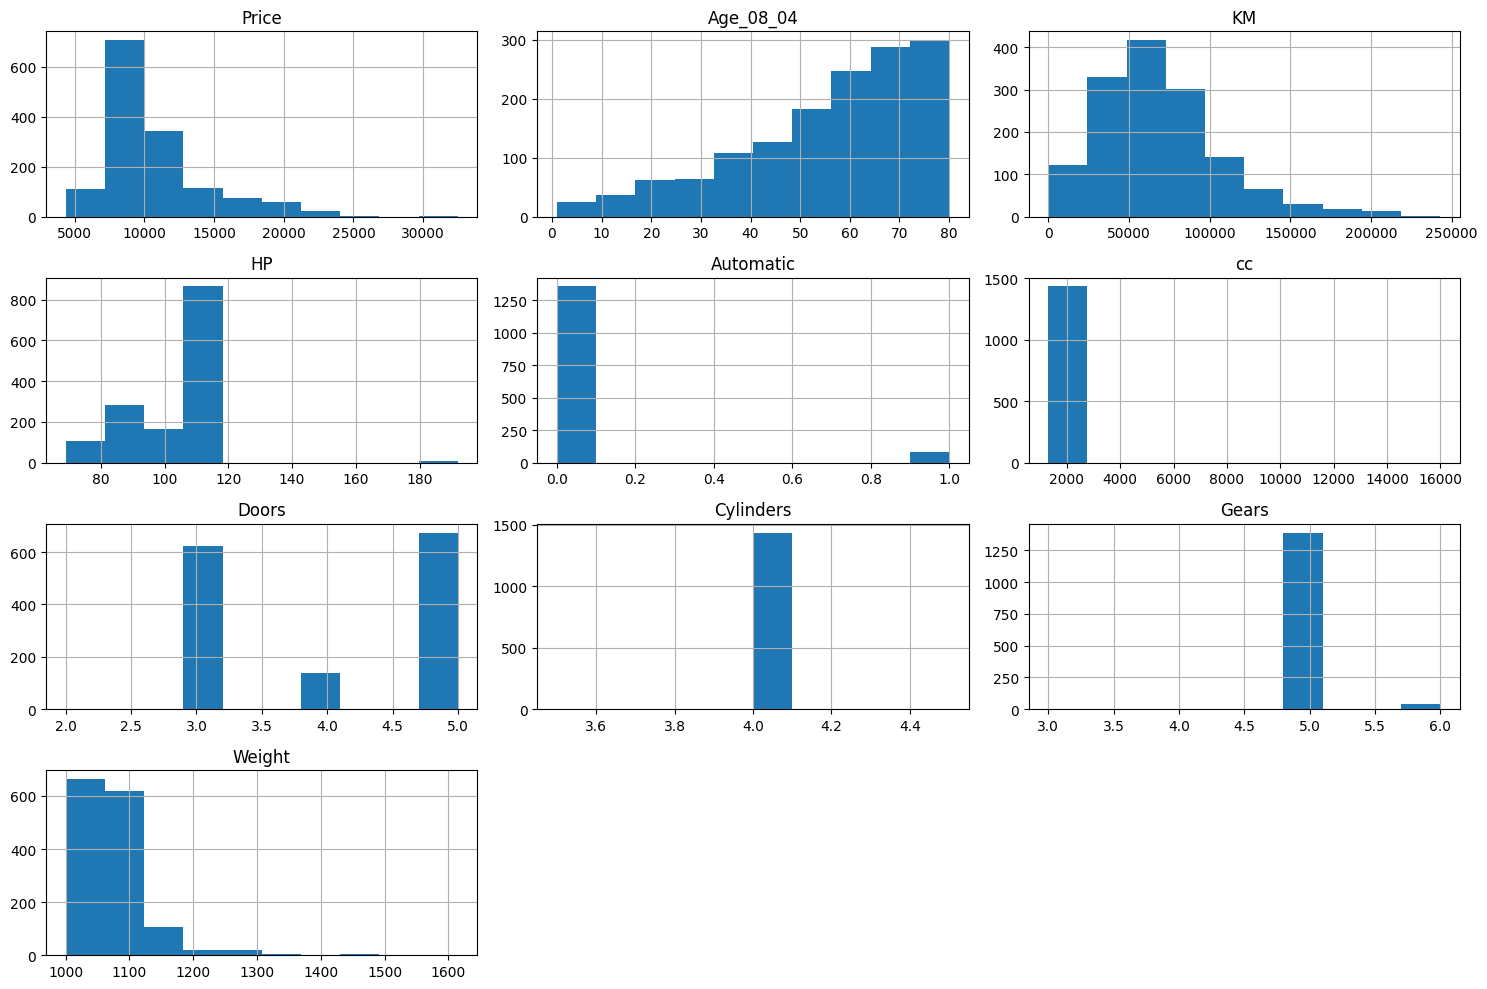

In [27]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Boxplot Visualization For Outlier Detection

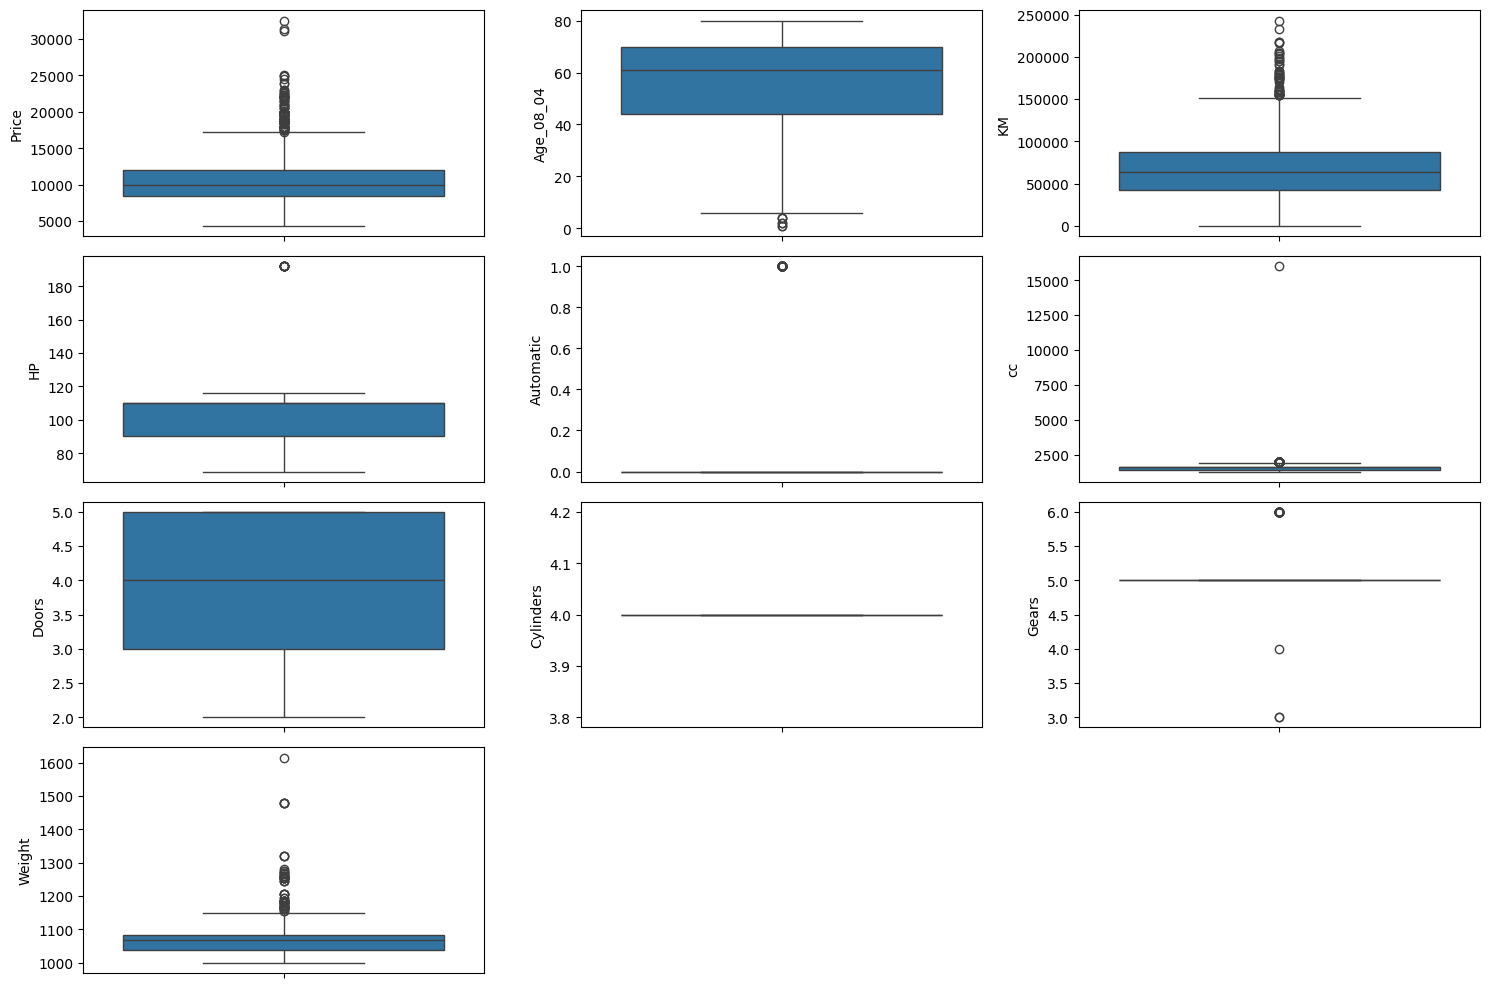

In [28]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    plt.subplot(4,3,i+1)
    sns.boxplot(df[col])

plt.tight_layout()
plt.show()

##  Correlation Heatmap

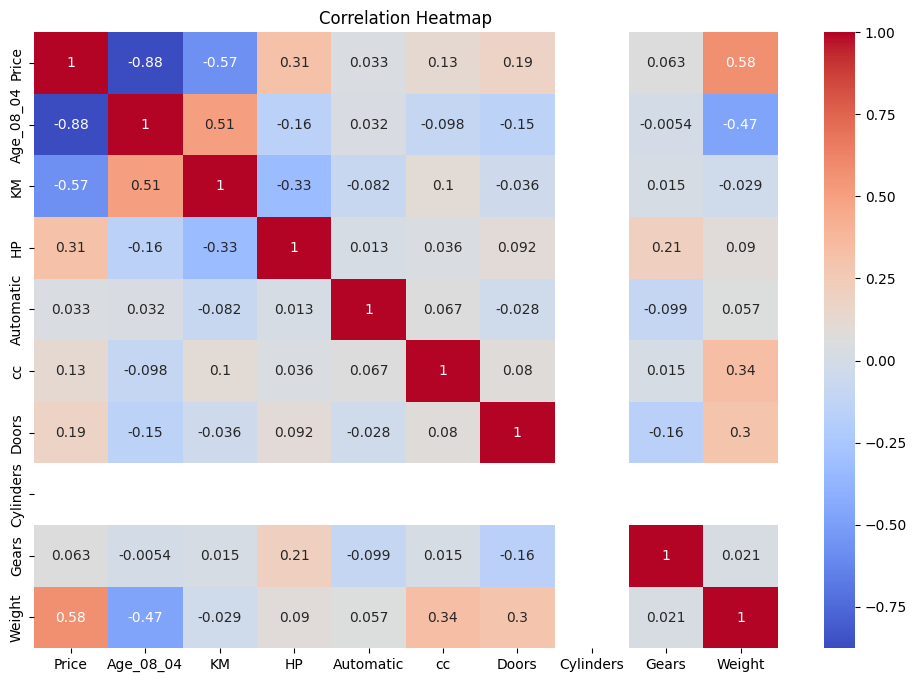

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Pairplot Visualization

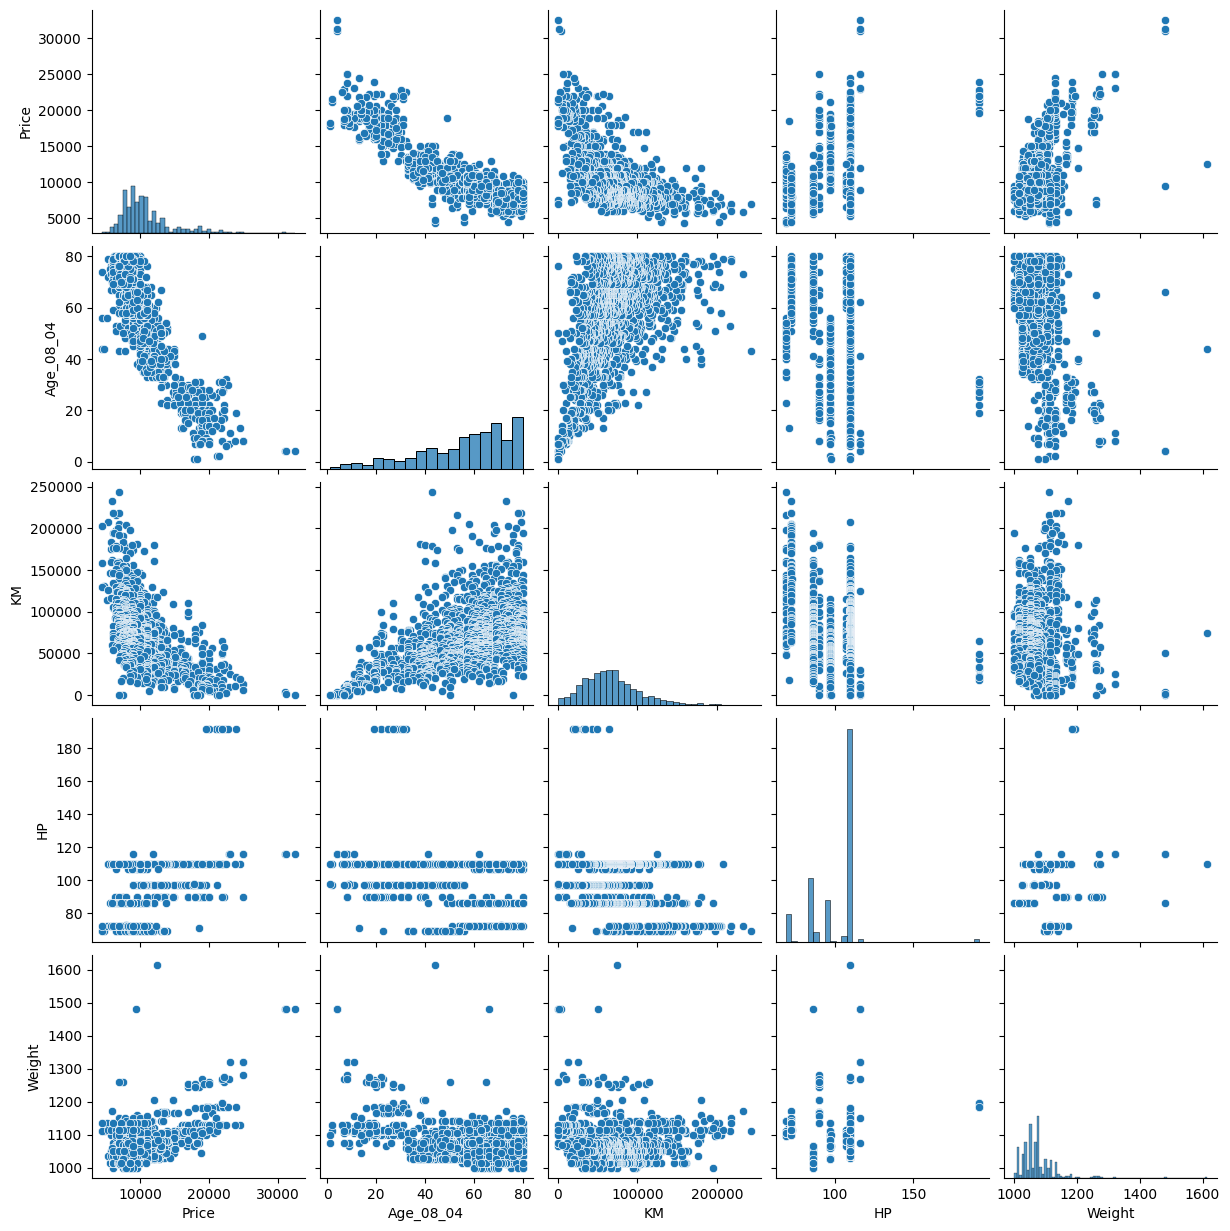

In [30]:
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

##  Countplot For Fuel Type

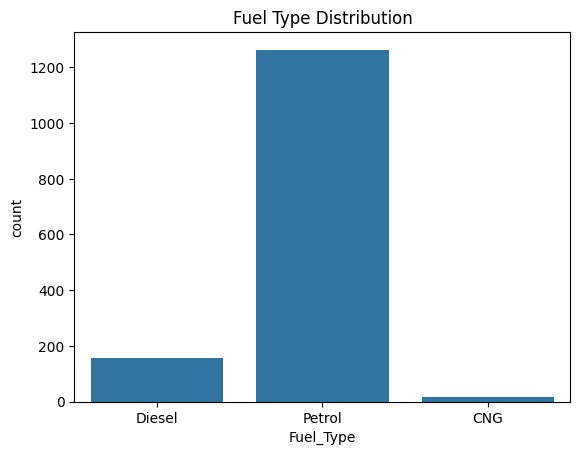

In [32]:

sns.countplot(x='Fuel_Type', data=df)
plt.title("Fuel Type Distribution")
plt.show()


######  1. Dataset contains both numerical and categorical variables.
######  2. Some variables contain outliers.
######  3. Strong correlations exist between certain variables.
######  4. Fuel types are unevenly distributed.
######  5. Data preprocessing is required before model building.

## Outlier Detection Using IQR Method

In [33]:
# Outlier Detection Using IQR Method

num_cols = df.select_dtypes(include=np.number).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

##  Removing Outliers

In [34]:
# Removing Outliers

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape

(1098, 11)

## Encoding Categorical Variables

In [35]:
# Encoding Categorical Variables

df = pd.get_dummies(df,
                    columns=['Fuel_Type'],
                    drop_first=True)

df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
9,12950,23,71138,69,0,1900,3,4,5,1105,True,False
18,16750,24,25563,110,0,1600,3,4,5,1065,False,True
19,16950,30,64359,110,0,1600,3,4,5,1105,False,True
20,15950,30,67660,110,0,1600,3,4,5,1105,False,True
22,15950,28,56349,110,0,1600,3,4,5,1120,False,True


## Feature And Target Variable

In [36]:
X = df.drop('Price', axis=1)
y = df['Price']

##  Feature Scaling


In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train Test Split

In [39]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

## Multiple Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Intercept & Coefficients

In [52]:
# Intercept & Coefficients
print("Intercept:", lr_model.intercept_)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coeff_df

Intercept: 10042.916413814748


,Feature,Coefficient
0,Age_08_04,-1.731111e+03
1,KM,-3.777693e+02
2,HP,-1.548551e+03
3,Automatic,-1.989520e-13
4,cc,1.433795e+03
5,Doors,-8.270901e+01
6,Cylinders,0.000000e+00
7,Gears,0.000000e+00
8,Weight,6.435385e+02
9,Fuel_Type_Diesel,-1.539400e+03



###### 1. Intercept represents base price when all features are zero.
###### 2. Positive coefficient means feature increases price.
###### 3. Negative coefficient means feature decreases price.
###### 4. KM and Age usually have negative impact on Price.
###### 5. HP and Weight generally increase the Price.

## Predictions

In [42]:
y_pred = lr_model.predict(X_test)

## Model Evaluation

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:",mse)
print("RMSE:", rmse)
print("r2_score:", r2)

MAE: 776.7350307720142
MSE: 962887.7658821441
RMSE: 981.2684474098534
r2_score: 0.8354072203180043


## Ridge Regression

In [46]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

##  Ridge Evaluation

In [47]:
mae_r = mean_absolute_error(y_test, ridge_pred)
mse_r = mean_squared_error(y_test, ridge_pred)
rmse_r = np.sqrt(mse_r)
r2_r = r2_score(y_test, ridge_pred)

print("MAE_r:", mae_r)
print("MSE_r:", mse_r)
print("RMSE_r:", rmse_r)
print("r2_score_r:", r2_r)

MAE_r: 777.0599924972457
MSE_r: 975724.6780614322
RMSE_r: 987.787769746838
r2_score_r: 0.8332129219449359


## Lasso Regression

In [49]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

## Lasso Evaluation

In [50]:
mae_l = mean_absolute_error(y_test, lasso_pred)
mse_l = mean_squared_error(y_test, lasso_pred)
rmse_l = np.sqrt(mse_l)
r2_l = r2_score(y_test, lasso_pred)

print("MAE_l:", mae_l)
print("MSE_l:", mse_l)
print("RMSE_l:", rmse_l)
print("r2_score_l:", r2_l)

MAE_l: 776.7502242565262
MSE_l: 963827.721317562
RMSE_l: 981.7472797607142
r2_score_l: 0.8352465475133697



######  1. Multiple Linear Regression, Ridge, and Lasso models were implemented.
######  2. Ridge and Lasso help reduce overfitting using regularization.
######  3. Model performance is compared using MAE, MSE, RMSE, and R2 score.
######  4. Best model can be selected based on highest R2 and lowest error.
######  5. Scaling and outlier removal improved model stability.

# Interview Questions:

#### 1.What is Normalization & Standardization and how is it helpful?

###### Normalization scales data between 0 and 1, while Standardization scales data to mean=0 and std=1.
###### It helps improve model performance and convergence.

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

###### We can handle it using:
######  Removing highly correlated variables
######  Using VIF (Variance Inflation Factor)
######  Applying Ridge Regression
######  PCA (Dimensionality Reduction)